# Tarea 2 - Análisis de Datos, Tendencias Tecnológicas y metodologías.

Autor: Jerónimo Ramos Ruiz

# Analisis de los datos sintéticos de ventas

En este notebook se realizará el cargado de los datos sintéticos de ventas para el desarrollo de los ejercicios de la Tarea 2 Análisis de Datos, Tendencias Tecnológicas
y metodologías. Para este caso se utilizara el lenguaje de programación de Python y su conexión con Apache Spark.

Dentro del desarrollo del ejercicio, se realizará un análisis exploratorio de un conjunto de datos de ventas proporcionado. Se va a comenzar estableciendo la conexión entre Python y Spark mediante la librería pyspark, para luego importar el archivo CSV generado con los generadores de dataset (Anexo 1 - generador_python.py) de ventas proporcionado.

A continuación, se realizará un análisis exploratorio que incluye estadísticas descriptivas básicas, se examinarán las distribuciones de las ventas y se calculán resúmenes por períodos de tiempo. Así mismo, se identificarán y documentaran los patrones encontrados, prestando especial atención a las tendencias mensuales, comportamientos estacionales y posibles correlaciones entre variables.

Para finalizar, nos aseguraremos de cerrar correctamente la conexión con Spark.

In [2]:
# Se importarán las bibliotecas necesarias
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Conexión con Spark

Antes de importar los datos, se creará la sesión de spark 

In [3]:
# Establecer sesión de Spark
spark = SparkSession.builder \
    .appName("AnalisisVentasEcommerce") \
    .getOrCreate()

print("Conexión con Spark establecida con éxito.")

Conexión con Spark establecida con éxito.


## Importación de los datos

Una vez se ejecuta el archivo: *Anexo 1 -  generador_python.py* para generar el dataset sintético de ventas, llamado *ventas_2023.csv* y sus anexos, se procederá a cargar para realizar el análisis descriptivo e identificación de tendencias.

In [6]:
# Leer el dataset
df_ventas = spark.read.csv("ventas_2023.csv", header=True, inferSchema=True)

# Se convierte la columna de fecha a tipo Timestamp si no lo es
df_ventas = df_ventas.withColumn("fecha", F.to_timestamp("fecha"))

print("Esquema del DataFrame en Spark")
df_ventas.printSchema()

print("Primeras cinco (5) filas del Dataset")
df_ventas.show(5)


Esquema del DataFrame en Spark
root
 |-- fecha: timestamp (nullable = true)
 |-- monto: double (nullable = true)
 |-- producto: string (nullable = true)
 |-- region: string (nullable = true)
 |-- tipo_pago: string (nullable = true)
 |-- cantidad: integer (nullable = true)
 |-- mes: integer (nullable = true)
 |-- dia_semana: string (nullable = true)

Primeras cinco (5) filas del Dataset
+-------------------+-------+----------+------+---------+--------+---+----------+
|              fecha|  monto|  producto|region|tipo_pago|cantidad|mes|dia_semana|
+-------------------+-------+----------+------+---------+--------+---+----------+
|2023-01-01 00:00:00| 786.92|Smartphone|  Este|  Crédito|       5|  1|   Domingo|
|2023-01-02 00:00:00|1211.86|Smartwatch| Oeste|   Débito|      10|  1|     Lunes|
|2023-01-03 00:00:00|1072.96|Smartphone|  Este|  Crédito|       6|  1|    Martes|
|2023-01-04 00:00:00| 713.16|Smartwatch|  Este| Efectivo|       3|  1| Miércoles|
|2023-01-05 00:00:00| 907.09|    Lapt

Inicialmente, podemos observar que el dataset se encuentra conformado por 8 columnas con la información de las ventas totales diarias del año 2023 de diferentes productos electrónicos según las regiones donde se encuentran las tiendas e identificando los medios de pago utilizados.

In [7]:
# Obtenemos los valores únicos para las columnas de interés
columnas_interes = ["producto", "region", "tipo_pago", "dia_semana"]

for col in columnas_interes:
    print(f"Valores únicos en {col}:")
    df_ventas.select(col).distinct().show()

Valores únicos en producto:
+----------+
|  producto|
+----------+
|Smartwatch|
|    Laptop|
|    Tablet|
|Smartphone|
+----------+

Valores únicos en region:
+------+
|region|
+------+
|   Sur|
| Oeste|
|  Este|
| Norte|
+------+

Valores únicos en tipo_pago:
+---------+
|tipo_pago|
+---------+
|  Crédito|
| Efectivo|
|   Débito|
+---------+

Valores únicos en dia_semana:
+----------+
|dia_semana|
+----------+
|    Martes|
| Miércoles|
|    Jueves|
|    Sábado|
|     Lunes|
|   Domingo|
|   Viernes|
+----------+



Adicionalmente, se evidencia que se cuenta con el registro de 4 productos electrónicos, los cuales son: Smartwatch, Laptop, Tablet y Smartphone; por otro lado, se identifican 4 regiones: Norte, Sur, Este y Oeste. En cuanto a los métodos de pago disponible, se tienen: Crédito, Efectivo y Débito. Finalmente, se puede observar que se cuenta con el registro de, al menos, cada uno de los días de la semana.

## Análisis Exploratorio y Estadísticas Descriptivas

In [8]:
# Obtenemos estadísticas descriptivas de las variables numéricas
df_ventas.describe().select("summary",
                            F.round("monto",2).alias("Ventas"),
                            F.round("cantidad",2).alias("Cantidad")).show()

# Conteo de registros y valores nulos
print(f"Total de registros: {df_ventas.count()}")

+-------+-------+--------+
|summary| Ventas|Cantidad|
+-------+-------+--------+
|  count|  365.0|   365.0|
|   mean| 993.52|    5.43|
| stddev|  307.5|    2.78|
|    min| 329.35|     1.0|
|    max|1964.62|    10.0|
+-------+-------+--------+

Total de registros: 365


In [9]:
# Obtenemos la cantidad de registros para las columnas de interés
columnas_interes = ["producto", "region", "tipo_pago"]

for col in columnas_interes:
    print(f"Cantidad de registros por {col}:")
    df_ventas.select(col).groupby(col) \
    .agg(F.round(F.count(col),2).alias("total_registros")).orderBy(F.desc("total_registros")).show()

Cantidad de registros por producto:
+----------+---------------+
|  producto|total_registros|
+----------+---------------+
|Smartwatch|            108|
|Smartphone|             97|
|    Laptop|             81|
|    Tablet|             79|
+----------+---------------+

Cantidad de registros por region:
+------+---------------+
|region|total_registros|
+------+---------------+
| Norte|            101|
| Oeste|             98|
|  Este|             84|
|   Sur|             82|
+------+---------------+

Cantidad de registros por tipo_pago:
+---------+---------------+
|tipo_pago|total_registros|
+---------+---------------+
|  Crédito|            125|
| Efectivo|            123|
|   Débito|            117|
+---------+---------------+



Con los resultados anteriores, podemos observar que el data set se encuentra conformado por los datos de todo el año 2023. En promedio, las ventas fueron de $ 993,52 con un margen entre 329,35 y 1964,52. Por otro lado, el producto más vendido fue el SmartWatch, con 108 ventas registradas, seguido del Smartphone (97 ventas) y la laptop (81 ventas). De las regiones que más ventas registraron se encuentra la Norte, con 101 ventas, seguida de la Oeste (98 ventas) y la este (84 ventas). En cuanto a los métodos de pago utilizados, hay una distribución casi uniforme en la cantidad de pagos por los métodos disponibles.

## Resúmenes

In [11]:
# Se agrupan las ventas por mes, como son del año 2023, no necesitamos añadir una columna adicional con el año
ventas_mensuales = df_ventas.groupby("mes") \
    .agg(F.round(F.sum("monto"),2).alias("total_ventas")) \
    .orderBy(F.desc("total_ventas"))

ventas_mensuales.show()


+---+------------+
|mes|total_ventas|
+---+------------+
|  3|    39491.46|
|  5|    39269.01|
|  4|    38308.23|
|  2|     34805.1|
|  1|    33749.19|
|  6|    31884.84|
|  7|    28188.11|
| 12|    27215.82|
|  8|     23611.0|
| 11|    23594.27|
|  9|    21730.94|
| 10|    20785.68|
+---+------------+



Se puede observar que el mes con los mayores ventas registradas corresponde al mes de marzo y mayo con ventas acumuladas por \\$ 39.491,46 y \\$ 39269,01, respectivamente; mientras que el mes con menores ventas fue octubre con ventas por \\$ 20.785,68.

In [21]:
# Resumen por Producto
resumen_producto = df.groupBy("producto") \
    .agg(F.round(F.sum("monto"), 2).alias("total_monto")) \
    .orderBy(F.desc("total_monto"))

# Resumen por Sede (Región)
resumen_region = df.groupBy("region") \
    .agg(F.round(F.sum("monto"), 2).alias("total_monto")) \
    .orderBy(F.desc("total_monto"))

resumen_producto.show()
resumen_region.show()

+----------+-----------+
|  producto|total_monto|
+----------+-----------+
|Smartwatch|  108294.48|
|Smartphone|   97673.12|
|    Tablet|   80996.24|
|    Laptop|   75669.81|
+----------+-----------+

+------+-----------+
|region|total_monto|
+------+-----------+
| Norte|   102062.5|
| Oeste|   96425.38|
|  Este|   85770.63|
|   Sur|   78375.14|
+------+-----------+



Por otro lado, es posible observar que la distribución de las ventas totales sigue el mismo patrón de la cantidad de ventas realizadas por cada producto y región. La venta de Smartwatch lidera las ventas con un total de \\$ 108.294,48; seguido de los Smartphones con un acumulado de \\$ 97.673,12 y las Tablets por \\$ 80.996,24. Por otro lado, la sede con el mayor valor acumulado de ventas es la Norte con \\$ 102.062,5 y la que menores ventas presenta es la Sur con \$ 78.375,14

## Visualización de Tendencias

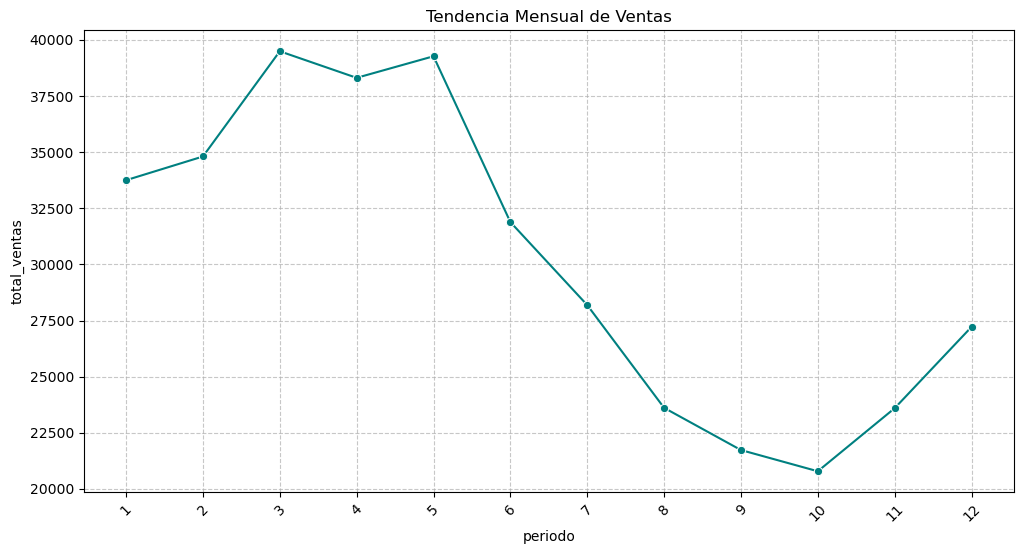

In [12]:
pd_ventas = ventas_mensuales.toPandas()
pd_ventas['periodo'] = pd_ventas['mes'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=pd_ventas, x='periodo', y='total_ventas', marker='o', color='teal')
plt.title('Tendencia Mensual de Ventas')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Como se puede observar en la gráfica anterior, las ventas presentan un incremento entre los meses de enero a marzo, con una leve disminución en abril y picos de ventas en marzo y mayo. Sin embargo, desde mayo se presenta una tendencia a disminuir hasta octubre donde vuelve a aumentar. Los picos presentados pueden deberse a celebraciones como el día de la mujer y de la madre donde la compra de ciertos productos electrónicos tiende a aumentar. Por otra parte, el aumento de ventas en noviembre y diciembre puede ser explicado por eventos como black Friday y navidad. Mientras que, para inicios del año, se puede deber a las promociones realizadas por las regiones para renovar el stock resagado del año anterior.

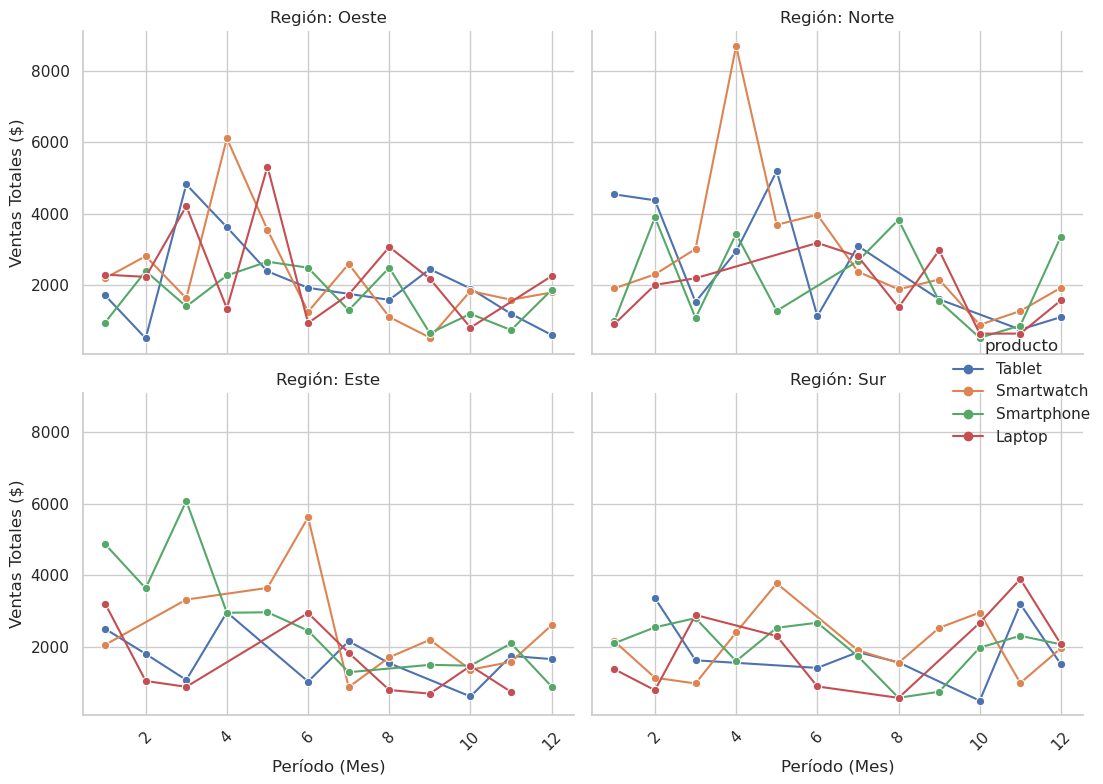

In [13]:
df_evolucion = df_ventas.groupBy("mes", "region", "producto") \
    .agg(F.sum("monto").alias("total_monto")) \
    .orderBy("mes")

# 2. Convertir a Pandas para graficar (el resumen suele ser pequeño)
df_plot = df_evolucion.toPandas()
df_plot['total_monto'] = df_plot['total_monto'].round(2)
# Configuración estética
sns.set_theme(style="whitegrid")

# Crear el gráfico: 
# - x: Tiempo
# - y: Monto
# - hue: Producto (colores distintos por producto)
# - col: Region (un gráfico al lado del otro por cada sede)
g = sns.relplot(
    data=df_plot, 
    x="mes", y="total_monto", 
    hue="producto", col="region",
    kind="line", marker="o", 
    col_wrap=2,
    height=4, aspect=1.2
)

# Ajustar etiquetas y rotación
g.set_axis_labels("Período (Mes)", "Ventas Totales ($)")
g.set_titles("Región: {col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Como se puede observar en la gráfica anterior, la venta de Smartwatchs en las regiones Oeste y Norte presentaron un pico de ventas en el mes de abril con una estacionalidad de dos meses en la región oeste, es decir, una tendencia a presentar picos cada dos meses. Por otro lado, se puede observar cierta correlación entre las ventas de algunos productos, por ejemplo, las ventas de Smartwatch tienden a ser inversamente proporcionales a las ventas de Laptops; así como las de Tablet tienden a ser inversamente proporcionales a las de Smartphone. Esto puede encontrarse relacionado con la dinámica de compra de los usuarios, donde adquieren uno u otro. 

Finalmente, se puede observar que hubo meses en los cuales no se realizaron ventas de productos como laptops o Smartwatchs en algunas de las regiones. 

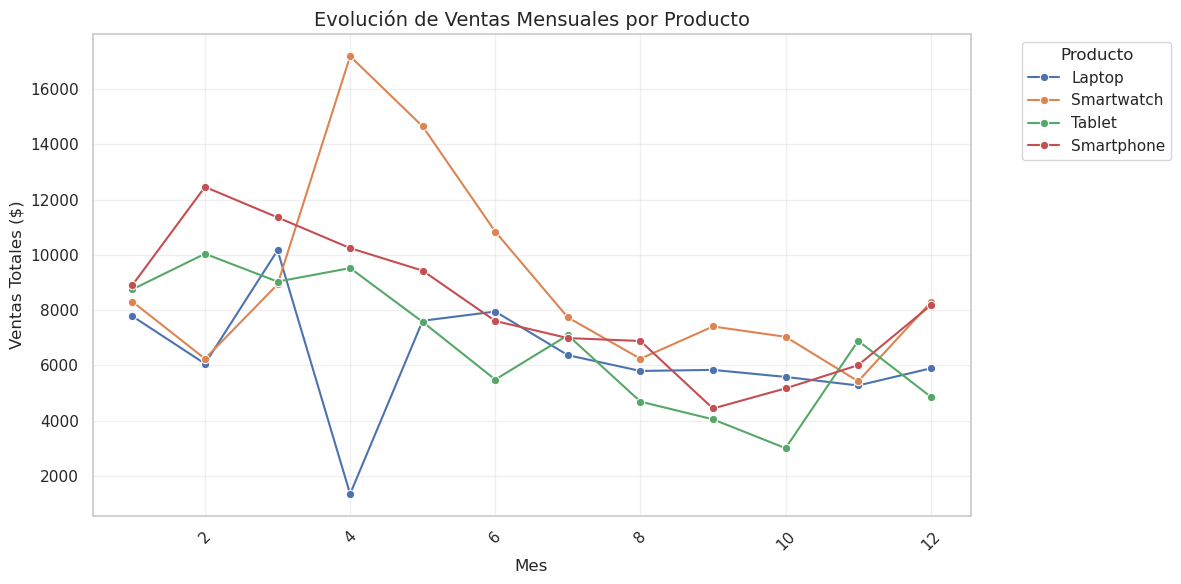

In [40]:
# Preparar datos temporales por producto
df_mes_producto = df.groupBy("mes", "producto") \
    .agg(F.sum("monto").alias("ventas_totales")) \
    .orderBy("mes")

# Convertir a Pandas para graficar
pd_mes_producto = df_mes_producto.toPandas()

# Ventas por Producto y Mes
plt.figure(figsize=(12, 6))
sns.lineplot(data=pd_mes_producto, x="mes", y="ventas_totales", hue="producto", marker="o")

plt.title("Evolución de Ventas Mensuales por Producto", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Ventas Totales ($)")
plt.xticks(rotation=45)
plt.legend(title="Producto", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

En la gráfica anterior, se pueden intuir las correlaciones previamente mencionadas, ya que el incremento de la venta de algunos productos como Smartwatch o Tablets, induce la reducción en la venta de otros productos como Laptops o Smartphones. Se puede observar que las ventas de Smartwatch presentaron un pico de ventas en el mes de abril, mientras que las ventas de Laptop tuvieron el mínimo de ventas en este mismo periodo.

Por otro lado, se puede observar un comportamiento general de las ventas donde hay una tendencia a presentar la reducción de venta de todos los productos después del mes de mayo hasta octubre. Esto puede encontrarse relacionado con la falta de fechas especiales durante este periodo de tiempo o periodos vacacionales donde la mayo parte de las personas se encuentra de viajes.

       Laptop  Smartphone  Smartwatch    Tablet
mes                                            
1     7780.05     8909.48     8306.59   8753.07
2     6060.24    12462.77     6240.82  10041.27
3    10166.85    11357.95     8933.07   9033.59
4     1344.16    10246.10    17194.56   9523.41
5     7616.87     9429.51    14650.91   7571.72


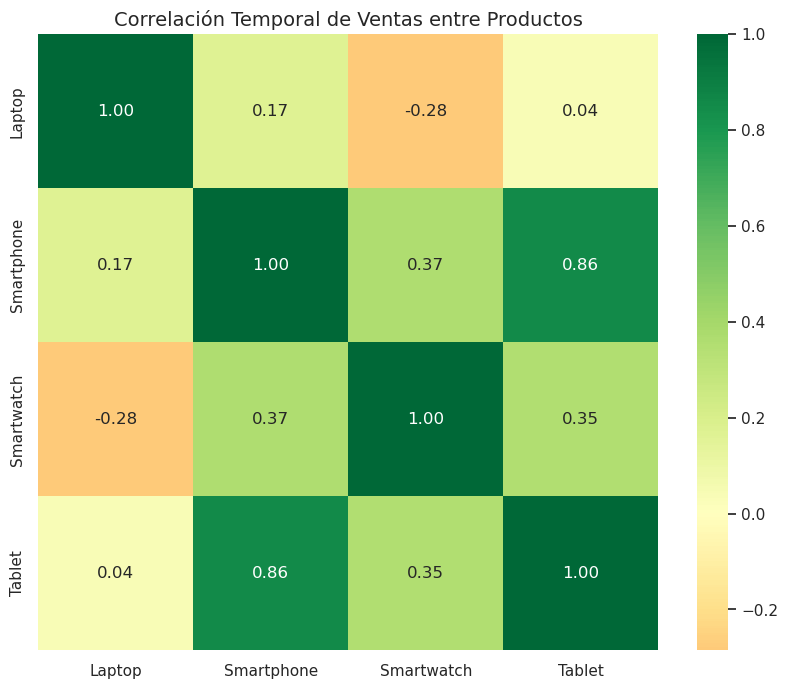

In [15]:
# Creamos una tabla con los productos como columnas y los meses como fila
df_mensual = df_ventas.groupBy("mes") \
    .pivot("producto") \
    .agg(F.sum("monto")) \
    .fillna(0)  # Llenar con 0 si un producto no tuvo ventas ese mes

# Convertimos a Pandas para calcular la correlación temporal
pd_correlacion = df_mensual.toPandas().set_index("mes").sort_index()

# Mostramos la tabla pivotada (Series temporales por producto)
print(pd_correlacion.head())

# Calculamos la matriz de correlación entre productos
matriz_corr = pd_correlacion.corr()

# Graficamos la matriz por medio de un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='RdYlGn', center=0, fmt=".2f")

plt.title("Correlación Temporal de Ventas entre Productos", fontsize=14)
plt.show()

Según la matriz de correlación, podemos observar que las apreciaciones inicialmente realizadas con respecto al comportamiento de los productos Smartwatch y Laptop no estában del todo equivocadas, pues estas presentan una correlación inversa. Sin embargo, contrario a lo observado inicialmente, productos como Smartphone y Tablets presentan una correlación fuerte entre estos. Por otro lado, se puede evidenciar que la venta de Tablets tiende a ser independiente de la compra de Laptops.

Con lo anteriormente dicho, se pueden llegar a proponer estrategias de negocio donde se pueden crear promociones o paquetes de compra en conjunto de los productos fuertemente correlacionados o balances de inventario según el comportamiento de las ventas de los productos con una correlación negativa identificada.

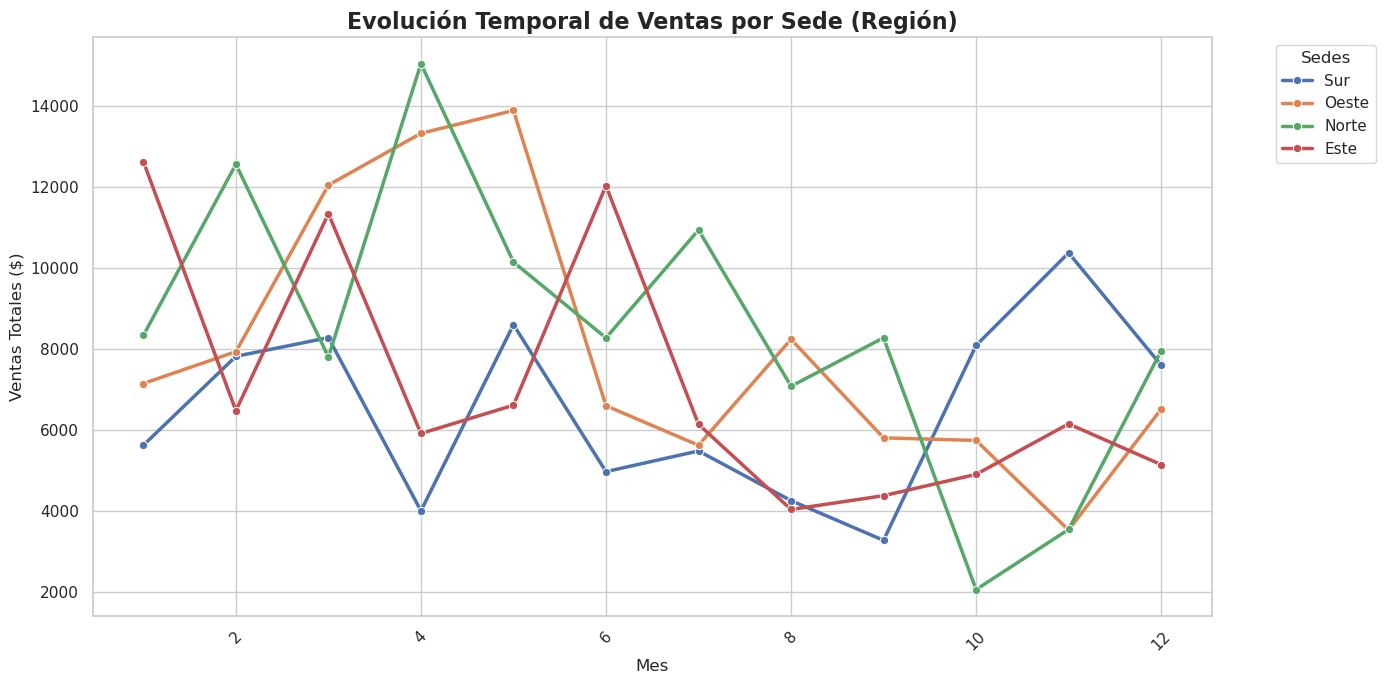

In [43]:
# Preparar datos por sede (región)
df_mes_sede = df.groupBy("mes", "region") \
    .agg(F.sum("monto").alias("ventas_totales")) \
    .orderBy(F.desc("mes"))

pd_mes_sede = df_mes_sede.toPandas()

# Visualización de Tendencias por Sede
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Dibujar las líneas por sede
sns.lineplot(
    data=pd_mes_sede, 
    x="mes", 
    y="ventas_totales", 
    hue="region", 
    marker="o", 
    linewidth=2.5
)

# Personalización del gráfico
plt.title("Evolución Temporal de Ventas por Sede (Región)", fontsize=16, fontweight='bold')
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Ventas Totales ($)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Sedes", bbox_to_anchor=(1.05, 1), loc='upper left')

# Formatear el eje Y para que no use notación científica si los montos son grandes
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

En la gráfica anterior podemos observar que la región que mantuvo un mayor balance de ventas fue la norte, mateniéndose con las mayores ventas durante aproximadamente 5 meses diferentes, aunque presentó un mínimo para todas las sedes en el mes de octubre. Por otro lado, aunque la región Sur fue la que menos ventas presentó a lo largo del año, en los meses de octubre y noviembre presentó las mayores ventas de todas las sedes.

## Cerrando la conexión con Spark

In [16]:
spark.stop()
print("Conexión con Spark cerrada correctamente.")

Conexión con Spark cerrada correctamente.
